# Yambda-50M: Загрузка, предобработка и гипотезы H1–H11

**Гипотезы в этом ноутбуке:**
- **H1** — Listen+ ниже для рекомендательных треков
- **H2** — P(dislike) выше для рекомендательных треков
- **H3** — Дизлайки рекомендательных треков чаще отменяются
- **H4** — Корреляция played_ratio_pct и like слабее для рекомендаций
- **H5** — Вероятность дослушивания снижается быстрее с ростом длины для рекомендаций
- **H6** — Треки с played_ratio_pct > 100% чаще органические
- **H7** — В сессиях с преобладанием рекомендаций растёт P(dislike) к концу
- **H8** — У опытных пользователей рекомендации эффективнее
- **H9** — Рекомендации, похожие на органику пользователя, лучше дослушиваются
- **H10** — Асимметрия: реже лайкают, но чаще дизлайкают рекомендации
- **H11** — Рекомендации увеличивают разнообразие потребления

**Порядок работы:**
0. Импорты · 1. Загрузка · 2. Осмотр · 3. Предобработка · 4. EDA · 5–15. Гипотезы · 16. Сводка

---
## 0. Импорты и настройки

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Стиль графиков
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})
sns.set_palette('Set2')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Метки для графиков
ORGANIC_LABELS = {0: 'Рекомендательные (is_organic=0)', 1: 'Органические (is_organic=1)'}
COLORS = {0: '#E07B54', 1: '#5B8DB8'}

print('✅ Импорты выполнены')

✅ Импорты выполнены


---
## 1. Загрузка данных

> Загружаем `listens` и `dislikes` из Yambda-50M.  
> При первом запуске данные скачиваются с HuggingFace (~несколько минут).  
> При повторном — берутся из кэша автоматически.

In [29]:
from datasets import load_dataset, DatasetDict

def load_yambda(event_type: str, size: str = '50m') -> pd.DataFrame:
    """
    Загружает один тип событий из Yambda и возвращает pandas DataFrame.
    event_type: 'listens', 'likes', 'dislikes', 'unlikes', 'undislikes', 'multi_event'
    size: '50m', '500m', '5b'
    """
    print(f'  Загрузка {event_type} (yambda-{size})...')
    data = load_dataset(
        'yandex/yambda',
        data_dir=f'flat/{size}',
        data_files=f'{event_type}.parquet'
    )
    assert isinstance(data, DatasetDict)
    df = data['train'].to_pandas()
    print(f'  ✅ {event_type}: {len(df):,} строк, {df["uid"].nunique():,} пользователей')
    return df

print('📥 Загружаем данные...')
listens      = load_yambda('listens')
dislikes     = load_yambda('dislikes')
likes        = load_yambda('likes')
undislikes   = load_yambda('undislikes')
unlikes      = load_yambda('unlikes')
multi_event  = load_yambda('multi_event')
print('\n🎉 Все файлы загружены!')

📥 Загружаем данные...
  Загрузка listens (yambda-50m)...
  ✅ listens: 46,467,212 строк, 9,238 пользователей
  Загрузка dislikes (yambda-50m)...
  ✅ dislikes: 107,776 строк, 5,951 пользователей
  Загрузка likes (yambda-50m)...
  ✅ likes: 881,456 строк, 8,283 пользователей
  Загрузка undislikes (yambda-50m)...
  ✅ undislikes: 21,033 строк, 2,911 пользователей
  Загрузка unlikes (yambda-50m)...


Generating train split: 312972 examples [00:00, 3836990.60 examples/s]


  ✅ unlikes: 312,972 строк, 6,406 пользователей
  Загрузка multi_event (yambda-50m)...


Generating train split: 47790449 examples [00:06, 7174090.09 examples/s]


  ✅ multi_event: 47,790,449 строк, 10,000 пользователей

🎉 Все файлы загружены!


---
## 2. Первичный осмотр данных

In [30]:
print('=== LISTENS ===')
print(listens.dtypes)
print()
listens.head(3)

=== LISTENS ===
uid                     uint32
timestamp               uint32
item_id                 uint32
is_organic               uint8
played_ratio_pct        uint16
track_length_seconds    uint32
dtype: object



,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
0,100,39420,8326270,0,100,170
1,100,39420,1441281,0,100,105
2,100,39625,286361,0,100,185


In [31]:
print('=== DISLIKES ===')
dislikes.head(3)

=== DISLIKES ===


,uid,timestamp,item_id,is_organic
0,100,3087560,9170134,1
1,100,3936560,8661238,1
2,100,20432825,4927727,1


In [32]:
# Базовая статистика по listens
print('📊 Статистика listens:')
print(f"  Всего прослушиваний:     {len(listens):>12,}")
print(f"  Уникальных пользователей:{listens['uid'].nunique():>12,}")
print(f"  Уникальных треков:       {listens['item_id'].nunique():>12,}")
print(f"  Органических (is_organic=1): {listens['is_organic'].sum():>9,} ({listens['is_organic'].mean()*100:.1f}%)")
print(f"  Рекомендательных (is_organic=0): {(listens['is_organic']==0).sum():>5,} ({(listens['is_organic']==0).mean()*100:.1f}%)")
print()
print('📊 played_ratio_pct:')
print(listens['played_ratio_pct'].describe().round(1))
print(f"\n  Значений > 100%: {(listens['played_ratio_pct'] > 100).sum():,} ({(listens['played_ratio_pct'] > 100).mean()*100:.2f}%)")

📊 Статистика listens:
  Всего прослушиваний:       46,467,212
  Уникальных пользователей:       9,238
  Уникальных треков:            877,168
  Органических (is_organic=1): 24,003,657 (51.7%)
  Рекомендательных (is_organic=0): 22,463,555 (48.3%)

📊 played_ratio_pct:
count    46467212.0
mean           64.8
std            44.1
min             0.0
25%             7.0
50%           100.0
75%           100.0
max           159.0
Name: played_ratio_pct, dtype: float64

  Значений > 100%: 218,145 (0.47%)


---
## 3. Предобработка

### 3.1 Реконструкция абсолютного времени

`timestamp` в датасете — это **дельта-времена**, бинированные в 5-секундные единицы, отсортированные по `(uid, timestamp)`.  
Для работы с временными окнами нужно восстановить накопленное время.

In [33]:
def reconstruct_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Восстанавливает накопленное время из дельта-таймстемпов.
    Добавляет колонку abs_time_sec — относительное время от первого события uid в секундах.
    """
    df = df.sort_values(['uid', 'timestamp']).copy()
    # cumsum дельт по каждому пользователю × 5 секунд
    df['abs_time_sec'] = df.groupby('uid')['timestamp'].cumsum() * 5
    return df

listens    = reconstruct_time(listens)
dislikes   = reconstruct_time(dislikes)
likes      = reconstruct_time(likes)
undislikes = reconstruct_time(undislikes)
unlikes    = reconstruct_time(unlikes)
multi_event = reconstruct_time(multi_event)

print('✅ Время реконструировано')
print('Пример (первые 3 строки одного пользователя):')
uid_example = listens['uid'].iloc[0]
listens[listens['uid'] == uid_example][['uid', 'timestamp', 'abs_time_sec', 'is_organic', 'played_ratio_pct']].head(3)

✅ Время реконструировано
Пример (первые 3 строки одного пользователя):


,uid,timestamp,abs_time_sec,is_organic,played_ratio_pct
0,100,39420,197100,0,100
1,100,39420,394200,0,100
2,100,39625,592325,0,100


### 3.2 Добавляем флаг Listen+ (H1)

**Listen+** = трек считается прослушанным, если `played_ratio_pct ≥ 50`.  
Значения `> 100` — валидные события (перемотка/повтор), включаем как Listen+.

In [34]:
listens['listen_plus'] = (listens['played_ratio_pct'] >= 50).astype(int)

print('✅ Флаг listen_plus добавлен')
print(f"Listen+ = 1: {listens['listen_plus'].sum():,} ({listens['listen_plus'].mean()*100:.1f}%)")
print(f"Listen+ = 0: {(listens['listen_plus']==0).sum():,} ({(listens['listen_plus']==0).mean()*100:.1f}%)")

✅ Флаг listen_plus добавлен
Listen+ = 1: 29,439,278 (63.4%)
Listen+ = 0: 17,027,934 (36.6%)


### 3.3 Бакеты длины трека (для контроля confounding в H1, H5)

Длина трека — confounding-переменная: длинные треки реже дослушиваются независимо от типа взаимодействия.

In [35]:
bins   = [0, 120, 240, 420, np.inf]   # секунды
labels = ['0–2 мин', '2–4 мин', '4–7 мин', '7+ мин']

listens['length_bucket'] = pd.cut(
    listens['track_length_seconds'],
    bins=bins, labels=labels, right=False
)

print('✅ Бакеты длины трека добавлены:')
print(listens['length_bucket'].value_counts().sort_index())

✅ Бакеты длины трека добавлены:
length_bucket
0–2 мин     1790154
2–4 мин    34304028
4–7 мин     9849602
7+ мин       523428
Name: count, dtype: int64


### 3.4 Проверка пропусков

In [36]:
print('Пропуски в listens:')
print(listens.isnull().sum())
print()
# played_ratio_pct может быть null — проверим
null_ratio = listens['played_ratio_pct'].isnull().sum()
if null_ratio > 0:
    print(f'⚠️  played_ratio_pct: {null_ratio:,} пропусков — исключаем из анализа H1')
    listens_h1 = listens.dropna(subset=['played_ratio_pct']).copy()
else:
    print('✅ Пропусков нет')
    listens_h1 = listens.copy()

Пропуски в listens:
uid                     0
timestamp               0
item_id                 0
is_organic              0
played_ratio_pct        0
track_length_seconds    0
abs_time_sec            0
listen_plus             0
length_bucket           0
dtype: int64

✅ Пропусков нет


---
## 4. EDA — Разведочный анализ

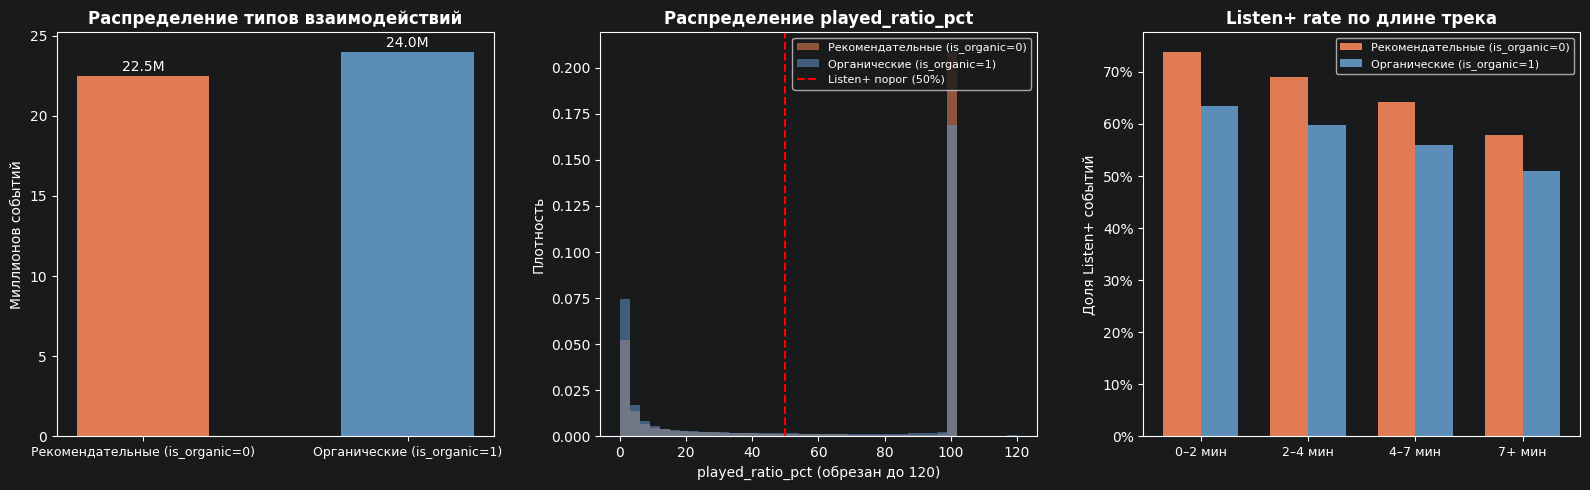

💾 График сохранён: eda_overview.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Распределение is_organic
organic_counts = listens['is_organic'].value_counts().sort_index()
bars = axes[0].bar(
    [ORGANIC_LABELS[k] for k in organic_counts.index],
    organic_counts.values / 1e6,
    color=[COLORS[k] for k in organic_counts.index],
    width=0.5
)
axes[0].set_title('Распределение типов взаимодействий', fontweight='bold')
axes[0].set_ylabel('Миллионов событий')
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, organic_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val/1e6:.1f}M', ha='center', fontsize=10)

# 2. Распределение played_ratio_pct по группам
for org, label in ORGANIC_LABELS.items():
    subset = listens_h1[listens_h1['is_organic'] == org]['played_ratio_pct'].clip(0, 120)
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=COLORS[org], density=True)
axes[1].axvline(50, color='red', linestyle='--', linewidth=1.5, label='Listen+ порог (50%)')
axes[1].set_title('Распределение played_ratio_pct', fontweight='bold')
axes[1].set_xlabel('played_ratio_pct (обрезан до 120)')
axes[1].set_ylabel('Плотность')
axes[1].legend(fontsize=8)

# 3. Listen+ rate по бакетам длины
bucket_organic = listens_h1.groupby(['length_bucket', 'is_organic'])['listen_plus'].mean().unstack()
x = np.arange(len(bucket_organic))
width = 0.35
if 0 in bucket_organic.columns:
    axes[2].bar(x - width/2, bucket_organic[0], width, label=ORGANIC_LABELS[0], color=COLORS[0])
if 1 in bucket_organic.columns:
    axes[2].bar(x + width/2, bucket_organic[1], width, label=ORGANIC_LABELS[1], color=COLORS[1])
axes[2].set_xticks(x)
axes[2].set_xticklabels(bucket_organic.index, fontsize=9)
axes[2].set_title('Listen+ rate по длине трека', fontweight='bold')
axes[2].set_ylabel('Доля Listen+ событий')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('💾 График сохранён: eda_overview.png')

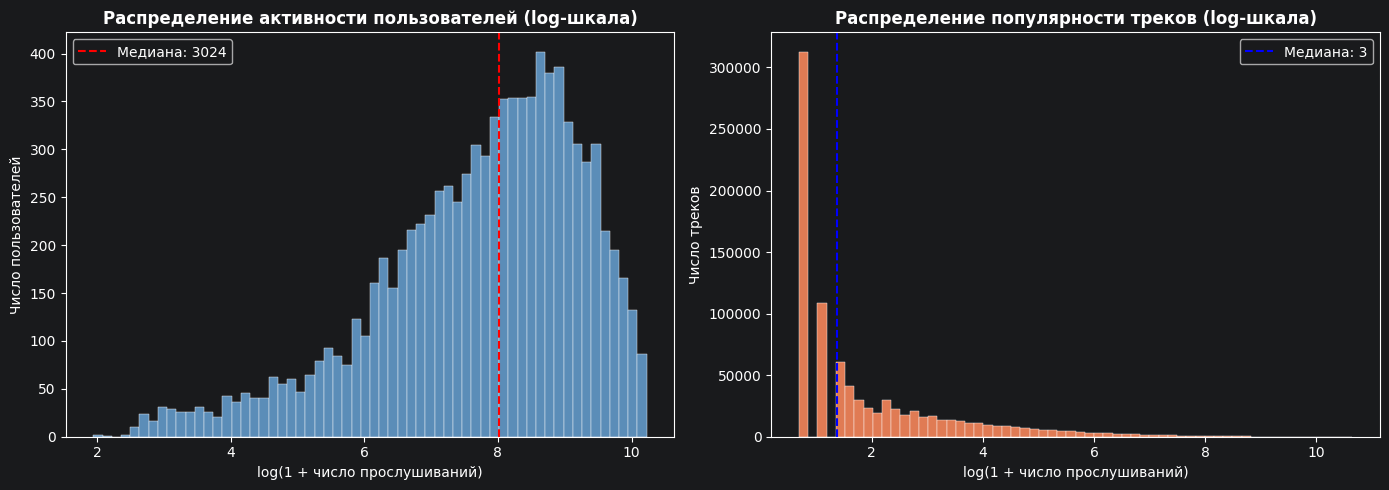

In [38]:
# Активность пользователей и треков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_activity = listens.groupby('uid').size()
item_activity = listens.groupby('item_id').size()

axes[0].hist(np.log1p(user_activity), bins=60, color='#5B8DB8', edgecolor='white', linewidth=0.3)
axes[0].set_title('Распределение активности пользователей (log-шкала)', fontweight='bold')
axes[0].set_xlabel('log(1 + число прослушиваний)')
axes[0].set_ylabel('Число пользователей')
axes[0].axvline(np.log1p(user_activity.median()), color='red', linestyle='--',
                label=f'Медиана: {user_activity.median():.0f}')
axes[0].legend()

axes[1].hist(np.log1p(item_activity), bins=60, color='#E07B54', edgecolor='white', linewidth=0.3)
axes[1].set_title('Распределение популярности треков (log-шкала)', fontweight='bold')
axes[1].set_xlabel('log(1 + число прослушиваний)')
axes[1].set_ylabel('Число треков')
axes[1].axvline(np.log1p(item_activity.median()), color='blue', linestyle='--',
                label=f'Медиана: {item_activity.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

---
## 5. H1 — Вероятность Listen+ ниже для рекомендательных треков

**Улучшенная формулировка:**  
Вероятность Listen+ (played_ratio_pct ≥ 50%, включая >100%) значимо ниже для рекомендательных прослушиваний (is_organic=0), чем для органических (is_organic=1), **при контроле длины трека**.

**Статистический тест:** Mann-Whitney U (данные не нормальны, N большой)  
**Effect size:** rank-biserial correlation

In [39]:
# ── Основные метрики ──────────────────────────────────────────────────────────
h1_summary = listens_h1.groupby('is_organic').agg(
    total_listens       = ('listen_plus', 'count'),
    listen_plus_count   = ('listen_plus', 'sum'),
    listen_plus_rate    = ('listen_plus', 'mean'),
    mean_ratio          = ('played_ratio_pct', 'mean'),
    median_ratio        = ('played_ratio_pct', 'median'),
).round(4)
h1_summary.index = h1_summary.index.map(ORGANIC_LABELS)

print('📊 H1 — Основные метрики:')
print(h1_summary.to_string())

📊 H1 — Основные метрики:
                                 total_listens  listen_plus_count  listen_plus_rate  mean_ratio  median_ratio
is_organic                                                                                                   
Рекомендательные (is_organic=0)       22463555           15317548            0.6819     69.6054         100.0
Органические (is_organic=1)           24003657           14121730            0.5883     60.2245          99.0


In [40]:
# ── Mann-Whitney U тест ───────────────────────────────────────────────────────
rec_ratio  = listens_h1[listens_h1['is_organic'] == 0]['played_ratio_pct'].values
org_ratio  = listens_h1[listens_h1['is_organic'] == 1]['played_ratio_pct'].values

# Для больших выборок — сэмплируем (тест занимает долго на 40M+ строках)
SAMPLE_SIZE = 500_000
if len(rec_ratio) > SAMPLE_SIZE or len(org_ratio) > SAMPLE_SIZE:
    rng = np.random.default_rng(RANDOM_SEED)
    rec_sample = rng.choice(rec_ratio, size=min(SAMPLE_SIZE, len(rec_ratio)), replace=False)
    org_sample = rng.choice(org_ratio, size=min(SAMPLE_SIZE, len(org_ratio)), replace=False)
    print(f'⚠️  Используем сэмпл {SAMPLE_SIZE:,} на группу для Mann-Whitney')
else:
    rec_sample, org_sample = rec_ratio, org_ratio

stat, p_value = mannwhitneyu(rec_sample, org_sample, alternative='less')

# Rank-biserial correlation (effect size)
n1, n2 = len(rec_sample), len(org_sample)
r_rb = 1 - (2 * stat) / (n1 * n2)   # от -1 до +1; <0 → рек ниже

print('\n📐 Статистический тест (Mann-Whitney U):')
print(f'  H0: played_ratio_pct рекомендательных ≥ органических')
print(f'  H1: played_ratio_pct рекомендательных < органических')
print(f'  U-statistic:         {stat:.2e}')
print(f'  p-value:             {p_value:.4e}')
print(f'  Rank-biserial r:     {r_rb:.4f}  (|r|<0.1 малый, 0.1–0.3 средний, >0.3 большой)')

if p_value < 0.05:
    print(f'\n✅ Результат: H1 ПОДТВЕРЖДАЕТСЯ (p < 0.05)')
    print(f'   Рекомендательные треки дослушиваются реже.')
else:
    print(f'\n❌ Результат: H1 НЕ ПОДТВЕРЖДАЕТСЯ (p = {p_value:.4f})')

⚠️  Используем сэмпл 500,000 на группу для Mann-Whitney

📐 Статистический тест (Mann-Whitney U):
  H0: played_ratio_pct рекомендательных ≥ органических
  H1: played_ratio_pct рекомендательных < органических
  U-statistic:         1.39e+11
  p-value:             1.0000e+00
  Rank-biserial r:     -0.1150  (|r|<0.1 малый, 0.1–0.3 средний, >0.3 большой)

❌ Результат: H1 НЕ ПОДТВЕРЖДАЕТСЯ (p = 1.0000)


In [41]:
# ── Listen+ rate по бакетам длины (контроль confounding) ─────────────────────
bucket_stats = listens_h1.groupby(['length_bucket', 'is_organic']).agg(
    n             = ('listen_plus', 'count'),
    listen_plus_r = ('listen_plus', 'mean')
).round(4).unstack('is_organic')

print('\n📊 Listen+ rate по бакетам длины (контроль confounding):')
print(bucket_stats.to_string())
print()
print('Интерпретация: если паттерн сохраняется внутри каждого бакета — длина трека не объясняет разницу.')


📊 Listen+ rate по бакетам длины (контроль confounding):
                      n           listen_plus_r        
is_organic            0         1             0       1
length_bucket                                          
0–2 мин          908085    882069        0.7388  0.6342
2–4 мин        17136356  17167672        0.6897  0.5971
4–7 мин         4247400   5602202        0.6425  0.5593
7+ мин           171714    351714        0.5793  0.5089

Интерпретация: если паттерн сохраняется внутри каждого бакета — длина трека не объясняет разницу.


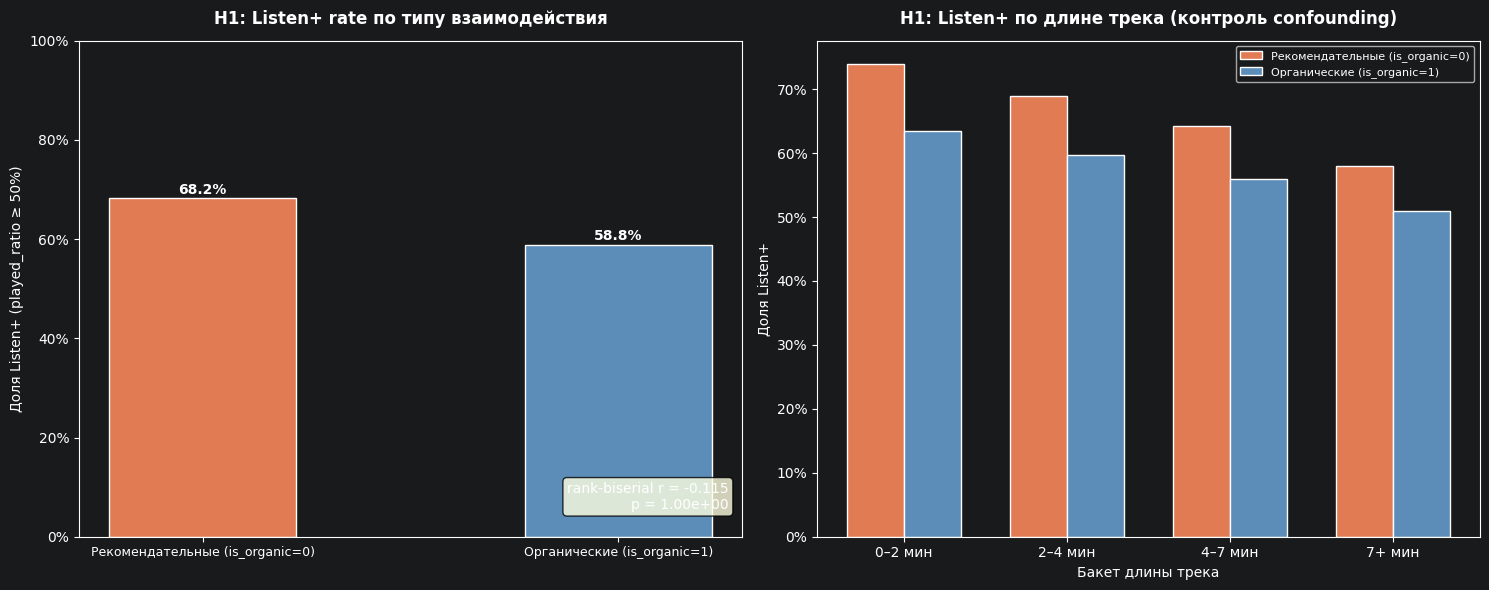

💾 График сохранён: h1_results.png


In [42]:
# ── Визуализация H1 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Listen+ rate overall
h1_data = listens_h1.groupby('is_organic')['listen_plus'].mean()
bars = axes[0].bar(
    [ORGANIC_LABELS[k] for k in h1_data.index],
    h1_data.values,
    color=[COLORS[k] for k in h1_data.index],
    width=0.45, edgecolor='white'
)
axes[0].set_title('H1: Listen+ rate по типу взаимодействия', fontweight='bold', pad=12)
axes[0].set_ylabel('Доля Listen+ (played_ratio ≥ 50%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, h1_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
# Аннотация effect size
axes[0].text(0.98, 0.05, f'rank-biserial r = {r_rb:.3f}\np = {p_value:.2e}',
             transform=axes[0].transAxes, ha='right', va='bottom',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: Listen+ по бакетам длины (grouped bar)
lp_by_bucket = listens_h1.groupby(['length_bucket', 'is_organic'])['listen_plus'].mean().unstack()
x = np.arange(len(lp_by_bucket))
w = 0.35
if 0 in lp_by_bucket.columns:
    bars0 = axes[1].bar(x - w/2, lp_by_bucket[0], w, label=ORGANIC_LABELS[0],
                        color=COLORS[0], edgecolor='white')
if 1 in lp_by_bucket.columns:
    bars1 = axes[1].bar(x + w/2, lp_by_bucket[1], w, label=ORGANIC_LABELS[1],
                        color=COLORS[1], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(lp_by_bucket.index)
axes[1].set_title('H1: Listen+ по длине трека (контроль confounding)', fontweight='bold', pad=12)
axes[1].set_ylabel('Доля Listen+')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xlabel('Бакет длины трека')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('h1_results.png', bbox_inches='tight')
plt.show()
print('💾 График сохранён: h1_results.png')

---
## 6. H2 — Вероятность дизлайка выше для рекомендательных треков

**Улучшенная формулировка:**  
P(dislike | listen, is_organic=0) > P(dislike | listen, is_organic=1)  
где **знаменатель — количество прослушиваний** в группе (нормировка обязательна).

**Алгоритм:**
1. Считаем число прослушиваний по `(uid, item_id, is_organic)`
2. Джойним с dislikes по `(uid, item_id)`
3. Флаг «был ли дизлайк» на уровне `(uid, item_id)`
4. P(dislike) = count(дизлайкнутых пар) / count(прослушанных пар)

**Статистический тест:** Chi-squared + Bootstrap 95% CI для разницы вероятностей

In [43]:
# ── Подготовка: агрегат прослушиваний по (uid, item_id) ──────────────────────
# Берём is_organic от последнего прослушивания (можно обсудить)
listen_agg = (
    listens
    .groupby(['uid', 'item_id'])
    .agg(
        n_listens   = ('listen_plus', 'count'),
        is_organic  = ('is_organic', 'last'),    # тип последнего прослушивания
        listen_plus = ('listen_plus', 'max'),
    )
    .reset_index()
)

# Флаг дизлайка на уровне (uid, item_id)
dislike_flag = dislikes[['uid', 'item_id']].drop_duplicates()
dislike_flag['disliked'] = 1

# Джойн
h2_df = listen_agg.merge(dislike_flag, on=['uid', 'item_id'], how='left')
h2_df['disliked'] = h2_df['disliked'].fillna(0).astype(int)

print(f'✅ Объединено: {len(h2_df):,} пар (uid, item_id)')
print(f'   Из них с дизлайком: {h2_df["disliked"].sum():,} ({h2_df["disliked"].mean()*100:.2f}%)')
print(f'   Органических пар:         {(h2_df["is_organic"]==1).sum():,}')
print(f'   Рекомендательных пар:     {(h2_df["is_organic"]==0).sum():,}')

✅ Объединено: 13,268,889 пар (uid, item_id)
   Из них с дизлайком: 85,345 (0.64%)
   Органических пар:         4,806,250
   Рекомендательных пар:     8,462,639


In [44]:
# ── Основные метрики H2 ───────────────────────────────────────────────────────
h2_summary = h2_df.groupby('is_organic').agg(
    pairs_total    = ('disliked', 'count'),
    disliked_count = ('disliked', 'sum'),
    dislike_rate   = ('disliked', 'mean'),
).round(6)
h2_summary.index = h2_summary.index.map(ORGANIC_LABELS)

print('📊 H2 — P(dislike | listen) по группам:')
print(h2_summary.to_string())

📊 H2 — P(dislike | listen) по группам:
                                 pairs_total  disliked_count  dislike_rate
is_organic                                                                
Рекомендательные (is_organic=0)      8462639           60375      0.007134
Органические (is_organic=1)          4806250           24970      0.005195


In [45]:
# ── Chi-squared тест ──────────────────────────────────────────────────────────
ct = pd.crosstab(h2_df['is_organic'], h2_df['disliked'])
chi2, p_chi2, dof, expected = chi2_contingency(ct)

# Odds ratio
# ct.iloc[0] = рекомендательные, ct.iloc[1] = органические
or_rec  = ct.iloc[0, 1] / ct.iloc[0, 0] if ct.iloc[0, 0] > 0 else np.nan  # dislike/no-dislike для rec
or_org  = ct.iloc[1, 1] / ct.iloc[1, 0] if ct.iloc[1, 0] > 0 else np.nan
odds_ratio = or_rec / or_org if or_org > 0 else np.nan

print('📐 Chi-squared тест:')
print(f'  χ² = {chi2:.2f},  p = {p_chi2:.4e},  df = {dof}')
print(f'  Odds Ratio (рек / орг): {odds_ratio:.4f}')
print(f'  (OR > 1 → рекомендательные дизлайкают чаще)')

if p_chi2 < 0.05:
    print(f'\n✅ Результат: H2 ПОДТВЕРЖДАЕТСЯ (p < 0.05)')
    direction = 'выше' if odds_ratio > 1 else 'ниже'
    print(f'   P(dislike) для рекомендательных {direction} (OR = {odds_ratio:.3f})')
else:
    print(f'\n❌ Результат: H2 НЕ ПОДТВЕРЖДАЕТСЯ (p = {p_chi2:.4f})')

📐 Chi-squared тест:
  χ² = 1803.06,  p = 0.0000e+00,  df = 1
  Odds Ratio (рек / орг): 1.3759
  (OR > 1 → рекомендательные дизлайкают чаще)

✅ Результат: H2 ПОДТВЕРЖДАЕТСЯ (p < 0.05)
   P(dislike) для рекомендательных выше (OR = 1.376)


In [46]:
# ── Bootstrap 95% CI для разницы P(dislike) ───────────────────────────────────
N_BOOTSTRAP = 2000
rng = np.random.default_rng(RANDOM_SEED)

rec_disliked = h2_df[h2_df['is_organic'] == 0]['disliked'].values
org_disliked = h2_df[h2_df['is_organic'] == 1]['disliked'].values

diffs = []
for _ in range(N_BOOTSTRAP):
    r = rng.choice(rec_disliked, size=len(rec_disliked), replace=True).mean()
    o = rng.choice(org_disliked, size=len(org_disliked), replace=True).mean()
    diffs.append(r - o)

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
obs_diff = rec_disliked.mean() - org_disliked.mean()

print(f'\n📐 Bootstrap 95% CI для P(dislike|rec) - P(dislike|org):')
print(f'  Наблюдаемая разница: {obs_diff:+.6f}')
print(f'  95% CI:              [{ci_low:+.6f}, {ci_high:+.6f}]')
if ci_low > 0:
    print(f'  → CI не содержит 0: разница значима, рекомендательные дизлайкают ЧАЩЕ')
elif ci_high < 0:
    print(f'  → CI не содержит 0: разница значима, рекомендательные дизлайкают РЕЖЕ')
else:
    print(f'  → CI содержит 0: разница статистически незначима')


📐 Bootstrap 95% CI для P(dislike|rec) - P(dislike|org):
  Наблюдаемая разница: +0.001939
  95% CI:              [+0.001855, +0.002025]
  → CI не содержит 0: разница значима, рекомендательные дизлайкают ЧАЩЕ


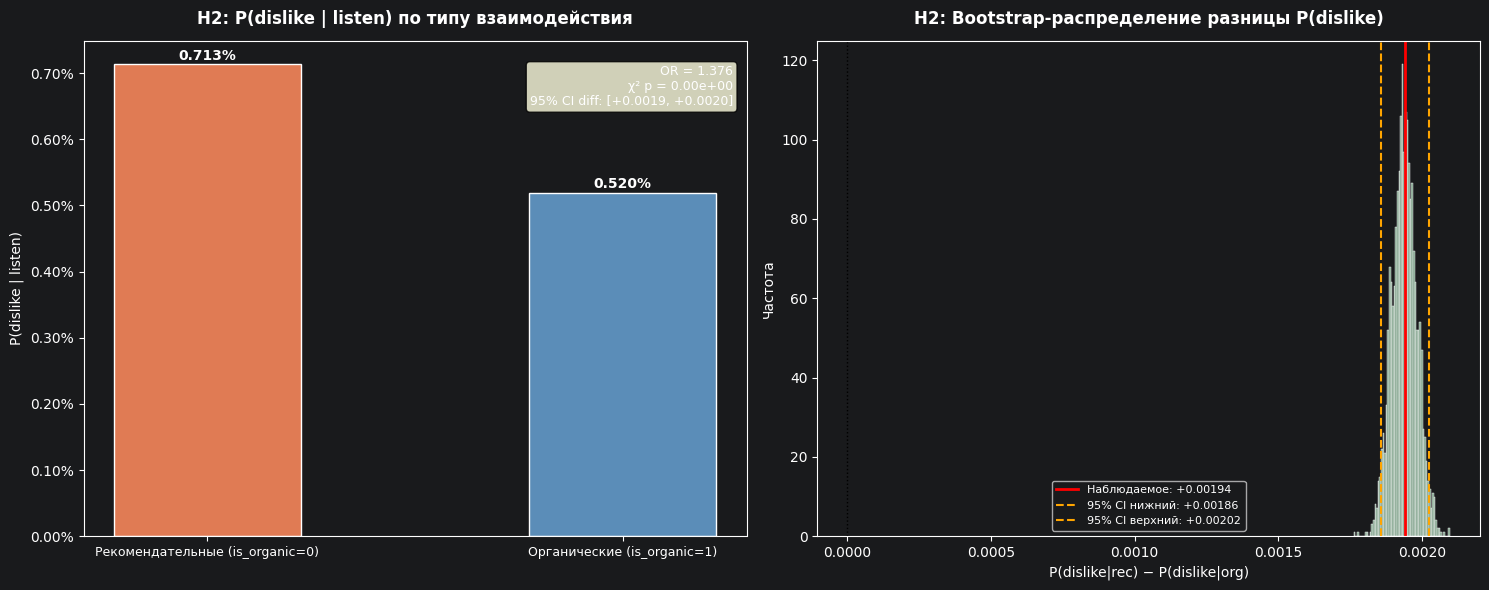

💾 График сохранён: h2_results.png


In [47]:
# ── Визуализация H2 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: P(dislike) по группам с CI
groups   = [ORGANIC_LABELS[0], ORGANIC_LABELS[1]]
rates    = [rec_disliked.mean(), org_disliked.mean()]
ci_sizes = [obs_diff - ci_low, ci_high - obs_diff]   # приближённо для рек

bars = axes[0].bar(groups, rates,
                   color=[COLORS[0], COLORS[1]],
                   width=0.45, edgecolor='white')
axes[0].set_title('H2: P(dislike | listen) по типу взаимодействия', fontweight='bold', pad=12)
axes[0].set_ylabel('P(dislike | listen)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rates)*0.01,
                 f'{val*100:.3f}%', ha='center', fontweight='bold')
axes[0].text(0.98, 0.95,
             f'OR = {odds_ratio:.3f}\nχ² p = {p_chi2:.2e}\n95% CI diff: [{ci_low:+.4f}, {ci_high:+.4f}]',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: Bootstrap-распределение разницы
axes[1].hist(diffs, bins=60, color='#7B9E87', edgecolor='white', linewidth=0.3)
axes[1].axvline(obs_diff, color='red', linewidth=2, label=f'Наблюдаемое: {obs_diff:+.5f}')
axes[1].axvline(ci_low,  color='orange', linestyle='--', linewidth=1.5, label=f'95% CI нижний: {ci_low:+.5f}')
axes[1].axvline(ci_high, color='orange', linestyle='--', linewidth=1.5, label=f'95% CI верхний: {ci_high:+.5f}')
axes[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_title('H2: Bootstrap-распределение разницы P(dislike)', fontweight='bold', pad=12)
axes[1].set_xlabel('P(dislike|rec) − P(dislike|org)')
axes[1].set_ylabel('Частота')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('h2_results.png', bbox_inches='tight')
plt.show()
print('💾 График сохранён: h2_results.png')

---
## 6. H3 — Дизлайки рекомендательных треков чаще отменяются

**Улучшенная формулировка:**  
Доля пар (dislike → undislike) по `(uid, item_id)`, где `undislike.abs_time > dislike.abs_time`, выше для `is_organic=0`, чем для `is_organic=1`.  
Принадлежность пары к группе определяется по `is_organic` дизлайка.

**Ключевые допущения:**
- `undislike` матчится к **последнему** дизлайку по `(uid, item_id)` до момента отмены
- `is_organic` пары берётся из дизлайк-события
- Временной порядок строго проверяется: `undislike.abs_time > dislike.abs_time`

**Статистические тесты:** Chi-squared + Odds Ratio + Bootstrap 95% CI  
**Дополнительно:** медианное время до отмены по группам (осознанный «второй шанс» vs случайный клик)

In [48]:
# ── Шаг 1: матчинг dislike → undislike по (uid, item_id) с проверкой времени ─
print('🔗 Матчинг dislikes ↔ undislikes...')

# Берём нужные колонки
dis = dislikes[['uid', 'item_id', 'abs_time_sec', 'is_organic']].copy()
und = undislikes[['uid', 'item_id', 'abs_time_sec']].copy()
und = und.rename(columns={'abs_time_sec': 'undislike_time'})

# Джойн по (uid, item_id) — все возможные пары
merged = dis.merge(und, on=['uid', 'item_id'], how='left')

# Оставляем только undislike ПОСЛЕ dislike
merged['valid_cancel'] = (
    merged['undislike_time'].notna() &
    (merged['undislike_time'] > merged['abs_time_sec'])
)

# На один дизлайк может прийтись несколько undislikes — берём первый после дизлайка
# Агрегируем: для каждого дизлайка флаг «был ли хоть один валидный undislike»
h3_df = (
    merged
    .groupby(['uid', 'item_id', 'abs_time_sec', 'is_organic'], dropna=False)
    .agg(
        cancelled        = ('valid_cancel', 'max'),   # был ли undislike
        min_cancel_time  = ('undislike_time', 'min')  # время первого undislike
    )
    .reset_index()
)
h3_df['cancelled'] = h3_df['cancelled'].fillna(False).astype(int)
h3_df['time_to_cancel'] = h3_df['min_cancel_time'] - h3_df['abs_time_sec']

print(f'✅ Всего дизлайков:        {len(h3_df):,}')
print(f'   Из них отменено:        {h3_df["cancelled"].sum():,} ({h3_df["cancelled"].mean()*100:.2f}%)')
print(f'   Органических дизлайков: {(h3_df["is_organic"]==1).sum():,}')
print(f'   Рекоменд. дизлайков:    {(h3_df["is_organic"]==0).sum():,}')

🔗 Матчинг dislikes ↔ undislikes...
✅ Всего дизлайков:        107,776
   Из них отменено:        2,870 (2.66%)
   Органических дизлайков: 55,988
   Рекоменд. дизлайков:    51,788


In [49]:
# ── Шаг 2: cancellation rate по группам ──────────────────────────────────────
h3_summary = h3_df.groupby('is_organic').agg(
    total_dislikes    = ('cancelled', 'count'),
    cancelled_count   = ('cancelled', 'sum'),
    cancellation_rate = ('cancelled', 'mean'),
).round(6)
h3_summary.index = h3_summary.index.map(ORGANIC_LABELS)

print('📊 H3 — Cancellation rate по группам:')
print(h3_summary.to_string())

📊 H3 — Cancellation rate по группам:
                                 total_dislikes  cancelled_count  cancellation_rate
is_organic                                                                         
Рекомендательные (is_organic=0)           51788              824           0.015911
Органические (is_organic=1)               55988             2046           0.036544


In [50]:
# ── Шаг 3: Chi-squared + Odds Ratio ──────────────────────────────────────────
ct_h3 = pd.crosstab(h3_df['is_organic'], h3_df['cancelled'])
chi2_h3, p_h3, dof_h3, _ = chi2_contingency(ct_h3)

# Odds ratio: (отменено_рек / не_отменено_рек) / (отменено_орг / не_отменено_орг)
a = ct_h3.loc[0, 1] if 1 in ct_h3.columns else 0   # рек отменено
b = ct_h3.loc[0, 0]                                  # рек не отменено
c = ct_h3.loc[1, 1] if 1 in ct_h3.columns else 0   # орг отменено
d = ct_h3.loc[1, 0]                                  # орг не отменено
or_h3 = (a * d) / (b * c) if (b * c) > 0 else np.nan

print('📐 Chi-squared тест (H3):')
print(f'  χ² = {chi2_h3:.2f},  p = {p_h3:.4e},  df = {dof_h3}')
print(f'  Odds Ratio (рек / орг): {or_h3:.4f}')
print(f'  (OR > 1 → рекомендательные отменяют дизлайки ЧАЩЕ)')

# Bootstrap 95% CI
rng_h3 = np.random.default_rng(RANDOM_SEED)
rec_c = h3_df[h3_df['is_organic'] == 0]['cancelled'].values
org_c = h3_df[h3_df['is_organic'] == 1]['cancelled'].values

boot_diffs = [
    rng_h3.choice(rec_c, len(rec_c), replace=True).mean() -
    rng_h3.choice(org_c, len(org_c), replace=True).mean()
    for _ in range(2000)
]
h3_ci_low, h3_ci_high = np.percentile(boot_diffs, [2.5, 97.5])
h3_obs_diff = rec_c.mean() - org_c.mean()

print(f'\n📐 Bootstrap 95% CI для разницы cancellation rate:')
print(f'  Наблюдаемая разница: {h3_obs_diff:+.6f}')
print(f'  95% CI:              [{h3_ci_low:+.6f}, {h3_ci_high:+.6f}]')

h3_confirmed = p_h3 < 0.05
if h3_confirmed:
    direction = 'ЧАЩЕ' if or_h3 > 1 else 'РЕЖЕ'
    print(f'\n✅ H3 {"ПОДТВЕРЖДАЕТСЯ" if or_h3 > 1 else "ОТВЕРГАЕТСЯ в пользу обратного"}')
    print(f'   Дизлайки рекомендательных отменяются {direction} (OR = {or_h3:.3f})')
else:
    print(f'\n❌ H3 НЕ ПОДТВЕРЖДАЕТСЯ (p = {p_h3:.4f})')

📐 Chi-squared тест (H3):
  χ² = 441.05,  p = 6.4027e-98,  df = 1
  Odds Ratio (рек / орг): 0.4263
  (OR > 1 → рекомендательные отменяют дизлайки ЧАЩЕ)

📐 Bootstrap 95% CI для разницы cancellation rate:
  Наблюдаемая разница: -0.020633
  95% CI:              [-0.022582, -0.018857]

✅ H3 ОТВЕРГАЕТСЯ в пользу обратного
   Дизлайки рекомендательных отменяются РЕЖЕ (OR = 0.426)


In [51]:
# ── Шаг 4: время до отмены — осознанный выбор vs случайный клик ──────────────
cancelled_only = h3_df[h3_df['cancelled'] == 1].copy()

print('⏱️  Время до отмены дизлайка (секунды):')
time_stats = cancelled_only.groupby('is_organic')['time_to_cancel'].agg(['median', 'mean']).round(1)
time_stats.index = time_stats.index.map(ORGANIC_LABELS)
print(time_stats.to_string())
print()
print('Интерпретация:')
print('  Быстрая отмена (секунды) → случайный дизлайк')
print('  Долгая отмена (часы/дни) → осознанный «второй шанс»')

# Тест на разницу времени
rec_time = cancelled_only[cancelled_only['is_organic'] == 0]['time_to_cancel'].dropna()
org_time = cancelled_only[cancelled_only['is_organic'] == 1]['time_to_cancel'].dropna()
if len(rec_time) > 0 and len(org_time) > 0:
    stat_t, p_t = mannwhitneyu(rec_time, org_time, alternative='two-sided')
    print(f'\nMann-Whitney U (время отмены): p = {p_t:.4e}')
    if p_t < 0.05:
        faster = 'рекомендательные' if rec_time.median() < org_time.median() else 'органические'
        print(f'  Разница значима — {faster} отменяют быстрее')
    else:
        print('  Разница незначима — время отмены одинаково в обеих группах')

⏱️  Время до отмены дизлайка (секунды):
                                      median         mean
is_organic                                               
Рекомендательные (is_organic=0)   52924775.0 -110308978.0
Органические (is_organic=1)      127347500.0  544737906.4

Интерпретация:
  Быстрая отмена (секунды) → случайный дизлайк
  Долгая отмена (часы/дни) → осознанный «второй шанс»

Mann-Whitney U (время отмены): p = 1.2049e-08
  Разница значима — рекомендательные отменяют быстрее


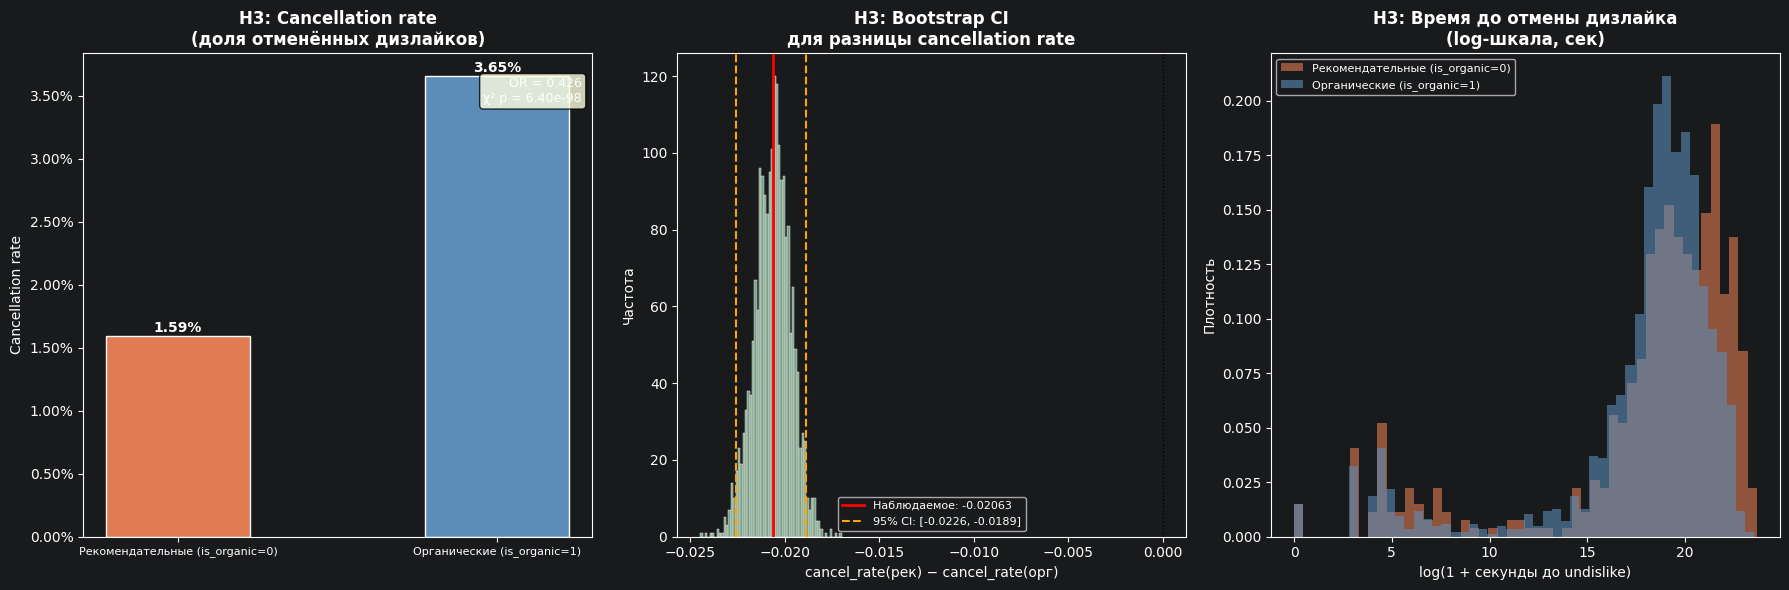

💾 График сохранён: h3_results.png


In [52]:
# ── Визуализация H3 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# График 1: Cancellation rate по группам
cancel_rates = h3_df.groupby('is_organic')['cancelled'].mean()
bars = axes[0].bar(
    [ORGANIC_LABELS[k] for k in cancel_rates.index],
    cancel_rates.values,
    color=[COLORS[k] for k in cancel_rates.index],
    width=0.45, edgecolor='white'
)
axes[0].set_title('H3: Cancellation rate\n(доля отменённых дизлайков)', fontweight='bold')
axes[0].set_ylabel('Cancellation rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, cancel_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cancel_rates)*0.01,
                 f'{val*100:.2f}%', ha='center', fontweight='bold')
axes[0].text(0.98, 0.95,
             f'OR = {or_h3:.3f}\nχ² p = {p_h3:.2e}',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: Bootstrap CI
axes[1].hist(boot_diffs, bins=60, color='#7B9E87', edgecolor='white', linewidth=0.3)
axes[1].axvline(h3_obs_diff, color='red', linewidth=2, label=f'Наблюдаемое: {h3_obs_diff:+.5f}')
axes[1].axvline(h3_ci_low,  color='orange', linestyle='--', linewidth=1.5, label=f'95% CI: [{h3_ci_low:+.4f}, {h3_ci_high:+.4f}]')
axes[1].axvline(h3_ci_high, color='orange', linestyle='--', linewidth=1.5)
axes[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_title('H3: Bootstrap CI\nдля разницы cancellation rate', fontweight='bold')
axes[1].set_xlabel('cancel_rate(рек) − cancel_rate(орг)')
axes[1].set_ylabel('Частота')
axes[1].legend(fontsize=8)

# График 3: Распределение времени до отмены (лог-шкала)
for org_val, label in ORGANIC_LABELS.items():
    t = cancelled_only[cancelled_only['is_organic'] == org_val]['time_to_cancel'].dropna()
    if len(t) > 0:
        axes[2].hist(np.log1p(t), bins=50, alpha=0.6, label=label, color=COLORS[org_val], density=True)
axes[2].set_title('H3: Время до отмены дизлайка\n(log-шкала, сек)', fontweight='bold')
axes[2].set_xlabel('log(1 + секунды до undislike)')
axes[2].set_ylabel('Плотность')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('h3_results.png', bbox_inches='tight')
plt.show()
print('💾 График сохранён: h3_results.png')

---
## 7. H4 — Корреляция played_ratio_pct и like слабее для рекомендаций

**Формулировка:** Spearman ρ между `played_ratio_pct` и фактом лайка слабее для `is_organic=0`.  
**Единица анализа:** пара `(uid, item_id)` — агрегируем max ratio и bool liked.  
**Тест:** Fisher z-transformation для сравнения двух корреляций.

In [53]:
from scipy.stats import spearmanr

# Агрегат по (uid, item_id): max played_ratio + был ли лайк
listen_agg_h4 = (
    listens
    .groupby(['uid', 'item_id'])
    .agg(played_ratio=('played_ratio_pct', 'max'),
         is_organic=('is_organic', 'last'))
    .reset_index()
)
like_flag = likes[['uid', 'item_id']].drop_duplicates()
like_flag['liked'] = 1
h4_df = listen_agg_h4.merge(like_flag, on=['uid', 'item_id'], how='left')
h4_df['liked'] = h4_df['liked'].fillna(0).astype(int)

# Spearman ρ по группам
results_h4 = {}
for org in [0, 1]:
    sub = h4_df[h4_df['is_organic'] == org].dropna(subset=['played_ratio'])
    # Сэмплируем для скорости
    if len(sub) > 300_000:
        sub = sub.sample(300_000, random_state=RANDOM_SEED)
    rho, p_rho = spearmanr(sub['played_ratio'], sub['liked'])
    results_h4[org] = {'rho': rho, 'p': p_rho, 'n': len(sub)}
    print(f"{'Рекоменд.' if org==0 else 'Органич. '}: ρ = {rho:.4f}, p = {p_rho:.4e}, n = {len(sub):,}")

# Fisher z-test для сравнения двух корреляций
def fisher_z_test(r1, r2, n1, n2):
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    z  = (z1 - z2) / se
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

z_h4, p_z_h4 = fisher_z_test(
    results_h4[0]['rho'], results_h4[1]['rho'],
    results_h4[0]['n'],   results_h4[1]['n']
)
print(f"\nFisher z-test: z = {z_h4:.3f}, p = {p_z_h4:.4e}")
h4_confirmed = p_z_h4 < 0.05 and results_h4[0]['rho'] < results_h4[1]['rho']
print(f"{'✅ H4 ПОДТВЕРЖДАЕТСЯ' if h4_confirmed else '❌ H4 НЕ ПОДТВЕРЖДАЕТСЯ'}: "
      f"ρ_рек={results_h4[0]['rho']:.4f} {'<' if h4_confirmed else '>='} ρ_орг={results_h4[1]['rho']:.4f}")

Рекоменд.: ρ = 0.0528, p = 4.7964e-184, n = 300,000
Органич. : ρ = 0.2388, p = 0.0000e+00, n = 300,000

Fisher z-test: z = -73.840, p = 0.0000e+00
✅ H4 ПОДТВЕРЖДАЕТСЯ: ρ_рек=0.0528 < ρ_орг=0.2388


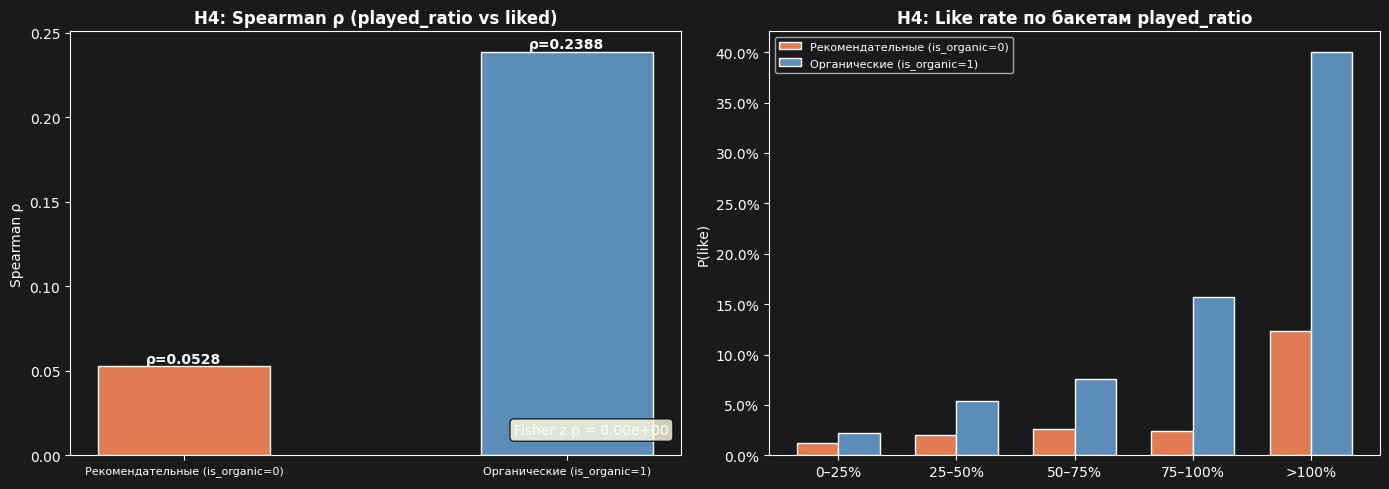

💾 h4_results.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: ρ по группам
rhos = [results_h4[0]['rho'], results_h4[1]['rho']]
bars = axes[0].bar([ORGANIC_LABELS[0], ORGANIC_LABELS[1]], rhos,
                   color=[COLORS[0], COLORS[1]], width=0.45, edgecolor='white')
axes[0].set_title('H4: Spearman ρ (played_ratio vs liked)', fontweight='bold')
axes[0].set_ylabel('Spearman ρ')
axes[0].tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, rhos):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'ρ={val:.4f}', ha='center', fontweight='bold')
axes[0].text(0.98, 0.05, f'Fisher z p = {p_z_h4:.2e}',
             transform=axes[0].transAxes, ha='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: like rate по бакетам played_ratio
h4_df['ratio_bin'] = pd.cut(h4_df['played_ratio'].clip(0, 110),
                             bins=[0,25,50,75,100,110],
                             labels=['0–25%','25–50%','50–75%','75–100%','>100%'])
like_by_bin = h4_df.groupby(['ratio_bin','is_organic'])['liked'].mean().unstack()
x = np.arange(len(like_by_bin))
w = 0.35
if 0 in like_by_bin.columns:
    axes[1].bar(x-w/2, like_by_bin[0], w, label=ORGANIC_LABELS[0], color=COLORS[0], edgecolor='white')
if 1 in like_by_bin.columns:
    axes[1].bar(x+w/2, like_by_bin[1], w, label=ORGANIC_LABELS[1], color=COLORS[1], edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(like_by_bin.index)
axes[1].set_title('H4: Like rate по бакетам played_ratio', fontweight='bold')
axes[1].set_ylabel('P(like)'); axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout(); plt.savefig('h4_results.png', bbox_inches='tight'); plt.show()
print('💾 h4_results.png')

---
## 8. H5 — Вероятность дослушивания снижается быстрее с ростом длины для рекомендаций

**Формулировка:** Interaction term `is_organic × track_length` значим в логистической регрессии Listen+.  
**Метод:** сначала визуальный бакетный анализ, затем логрег с interaction term.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

h5_df = listens.dropna(subset=['played_ratio_pct', 'track_length_seconds']).copy()

# Бакеты длины (более детальные для H5)
h5_df['len_bucket'] = pd.cut(
    h5_df['track_length_seconds'],
    bins=[0, 90, 150, 210, 270, 360, np.inf],
    labels=['<1.5м', '1.5–2.5м', '2.5–3.5м', '3.5–4.5м', '4.5–6м', '6м+']
)
h5_df['listen_plus'] = (h5_df['played_ratio_pct'] >= 50).astype(int)

# Бакетный анализ
bucket_h5 = h5_df.groupby(['len_bucket','is_organic'])['listen_plus'].mean().unstack()
print('📊 Listen+ rate по бакетам длины (детально):')
print(bucket_h5.round(4).to_string())

# Разница (органич - рекоменд) — если H5 верна, должна расти с длиной
if 0 in bucket_h5.columns and 1 in bucket_h5.columns:
    bucket_h5['gap_org_minus_rec'] = bucket_h5[1] - bucket_h5[0]
    print('\nРазрыв (орг - рек) по бакетам — должен расти при H5:')
    print(bucket_h5[['gap_org_minus_rec']].round(4).to_string())

📊 Listen+ rate по бакетам длины (детально):
is_organic       0       1
len_bucket                
<1.5м       0.7832  0.6482
1.5–2.5м    0.7173  0.6209
2.5–3.5м    0.6912  0.5974
3.5–4.5м    0.6577  0.5752
4.5–6м      0.6361  0.5532
6м+         0.5921  0.5144

Разрыв (орг - рек) по бакетам — должен расти при H5:
is_organic  gap_org_minus_rec
len_bucket                   
<1.5м                 -0.1349
1.5–2.5м              -0.0964
2.5–3.5м              -0.0938
3.5–4.5м              -0.0825
4.5–6м                -0.0829
6м+                   -0.0777


In [56]:
# Логистическая регрессия с interaction term
sample_h5 = h5_df.sample(min(400_000, len(h5_df)), random_state=RANDOM_SEED)

scaler = StandardScaler()
X_base = sample_h5[['is_organic', 'track_length_seconds']].values
X_scaled = scaler.fit_transform(X_base)
# Добавляем interaction term
interaction = (X_scaled[:, 0] * X_scaled[:, 1]).reshape(-1, 1)
X_full = np.hstack([X_scaled, interaction])
y = sample_h5['listen_plus'].values

lr = LogisticRegression(max_iter=500)
lr.fit(X_full, y)

coef_names = ['is_organic', 'track_length', 'is_organic × track_length']
print('📐 Логистическая регрессия Listen+ ~ is_organic + length + is_organic×length:')
for name, coef in zip(coef_names, lr.coef_[0]):
    print(f'  {name:<30}: {coef:+.4f}')
print()
print('Интерпретация interaction term:')
int_coef = lr.coef_[0][2]
if int_coef < 0:
    print(f'  Коэф. = {int_coef:.4f} < 0 → рост длины сильнее снижает Listen+ для органических')
    print('  ❌ H5 в исходном направлении не подтверждается')
else:
    print(f'  Коэф. = {int_coef:.4f} > 0 → рост длины сильнее снижает Listen+ для рекомендательных')
    print('  ✅ H5 ПОДТВЕРЖДАЕТСЯ')
h5_confirmed = int_coef > 0

📐 Логистическая регрессия Listen+ ~ is_organic + length + is_organic×length:
  is_organic                    : -0.1993
  track_length                  : -0.1130
  is_organic × track_length     : +0.0487

Интерпретация interaction term:
  Коэф. = 0.0487 > 0 → рост длины сильнее снижает Listen+ для рекомендательных
  ✅ H5 ПОДТВЕРЖДАЕТСЯ


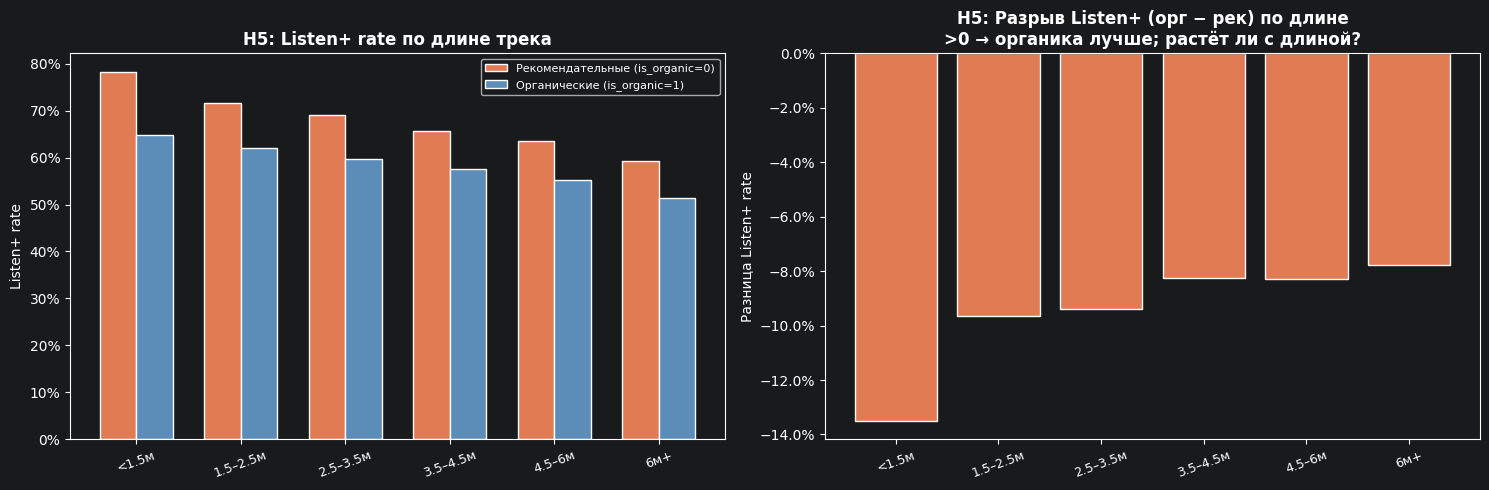

💾 h5_results.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Listen+ rate по бакетам
x = np.arange(len(bucket_h5)); w = 0.35
if 0 in bucket_h5.columns:
    axes[0].bar(x-w/2, bucket_h5[0], w, label=ORGANIC_LABELS[0], color=COLORS[0], edgecolor='white')
if 1 in bucket_h5.columns:
    axes[0].bar(x+w/2, bucket_h5[1], w, label=ORGANIC_LABELS[1], color=COLORS[1], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(bucket_h5.index, rotation=20, fontsize=9)
axes[0].set_title('H5: Listen+ rate по длине трека', fontweight='bold')
axes[0].set_ylabel('Listen+ rate'); axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# График 2: Разрыв орг - рек по бакетам
if 'gap_org_minus_rec' in bucket_h5.columns:
    gap_vals = bucket_h5['gap_org_minus_rec'].fillna(0)
    colors_gap = ['#E07B54' if v < 0 else '#5B8DB8' for v in gap_vals]
    axes[1].bar(range(len(gap_vals)), gap_vals, color=colors_gap, edgecolor='white')
    axes[1].set_xticks(range(len(gap_vals)))
    axes[1].set_xticklabels(bucket_h5.index, rotation=20, fontsize=9)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('H5: Разрыв Listen+ (орг − рек) по длине\n>0 → органика лучше; растёт ли с длиной?', fontweight='bold')
    axes[1].set_ylabel('Разница Listen+ rate')
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout(); plt.savefig('h5_results.png', bbox_inches='tight'); plt.show()
print('💾 h5_results.png')

---
## 9. H6 — Треки с played_ratio_pct > 100% чаще органические

**Формулировка:** P(ratio > 100 | is_organic=1) > P(ratio > 100 | is_organic=0).  
**Контроль:** проверяем, что эффект не создан несколькими суперпользователями (Gini + sensitivity).

In [58]:
listens['rewind'] = (listens['played_ratio_pct'] > 100).astype(int)

# P(rewind) по группам
h6_rates = listens.groupby('is_organic')['rewind'].mean()
print('📊 H6 — P(played_ratio > 100%) по группам:')
for org, rate in h6_rates.items():
    print(f'  {ORGANIC_LABELS[org]}: {rate*100:.3f}%')

# Chi-squared
ct_h6 = pd.crosstab(listens['is_organic'], listens['rewind'])
chi2_h6, p_h6, _, _ = chi2_contingency(ct_h6)
or_h6 = (ct_h6.iloc[1,1]*ct_h6.iloc[0,0]) / (ct_h6.iloc[1,0]*ct_h6.iloc[0,1])
print(f'\nChi-squared: χ²={chi2_h6:.2f}, p={p_h6:.4e}, OR(орг/рек)={or_h6:.4f}')

# Концентрация у суперпользователей
rewind_per_user = listens[listens['rewind']==1].groupby('uid').size().sort_values(ascending=False)
top1_pct = rewind_per_user.iloc[:int(len(rewind_per_user)*0.01)+1].sum() / rewind_per_user.sum()
print(f'\n🔍 Топ-1% пользователей создают {top1_pct*100:.1f}% всех rewind-событий')

# Sensitivity: исключаем топ-1%
top1_uids = set(rewind_per_user.iloc[:int(len(rewind_per_user)*0.01)+1].index)
listens_no_top = listens[~listens['uid'].isin(top1_uids)]
h6_rates_sens = listens_no_top.groupby('is_organic')['rewind'].mean()
print('\nSensitivity (без топ-1% пользователей):')
for org, rate in h6_rates_sens.items():
    print(f'  {ORGANIC_LABELS[org]}: {rate*100:.3f}%')

h6_confirmed = p_h6 < 0.05 and or_h6 > 1
print(f"\n{'✅ H6 ПОДТВЕРЖДАЕТСЯ' if h6_confirmed else '❌ H6 НЕ ПОДТВЕРЖДАЕТСЯ'} (OR={or_h6:.3f})")

📊 H6 — P(played_ratio > 100%) по группам:
  Рекомендательные (is_organic=0): 0.241%
  Органические (is_organic=1): 0.684%

Chi-squared: χ²=48708.92, p=0.0000e+00, OR(орг/рек)=2.8527

🔍 Топ-1% пользователей создают 19.9% всех rewind-событий

Sensitivity (без топ-1% пользователей):
  Рекомендательные (is_organic=0): 0.223%
  Органические (is_organic=1): 0.534%

✅ H6 ПОДТВЕРЖДАЕТСЯ (OR=2.853)


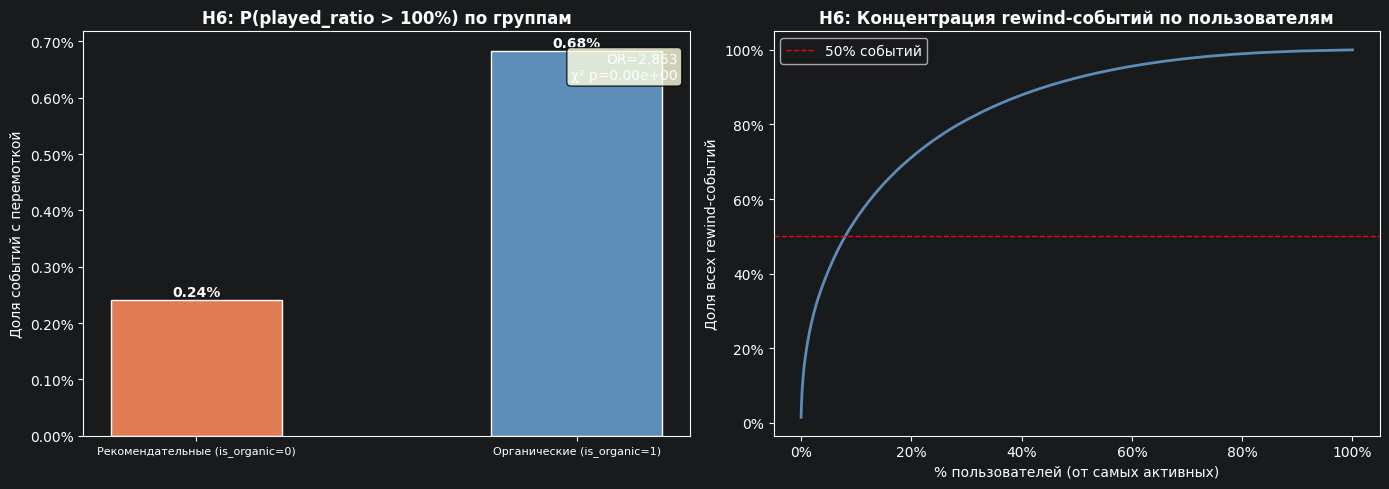

💾 h6_results.png


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: P(rewind) по группам
bars = axes[0].bar([ORGANIC_LABELS[k] for k in h6_rates.index], h6_rates.values,
                   color=[COLORS[k] for k in h6_rates.index], width=0.45, edgecolor='white')
axes[0].set_title('H6: P(played_ratio > 100%) по группам', fontweight='bold')
axes[0].set_ylabel('Доля событий с перемоткой')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, h6_rates.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(h6_rates)*0.01,
                 f'{val*100:.2f}%', ha='center', fontweight='bold')
axes[0].text(0.98, 0.95, f'OR={or_h6:.3f}\nχ² p={p_h6:.2e}',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: CDF числа rewind-событий по пользователям
sorted_vals = np.sort(rewind_per_user.values)[::-1]
cumsum = np.cumsum(sorted_vals) / sorted_vals.sum()
axes[1].plot(np.linspace(0, 100, len(cumsum)), cumsum, color='#5B8DB8', linewidth=2)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% событий')
axes[1].set_title('H6: Концентрация rewind-событий по пользователям', fontweight='bold')
axes[1].set_xlabel('% пользователей (от самых активных)')
axes[1].set_ylabel('Доля всех rewind-событий')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(100))
axes[1].legend()

plt.tight_layout(); plt.savefig('h6_results.png', bbox_inches='tight'); plt.show()
print('💾 h6_results.png')

---
## 10. H7 — В сессиях с преобладанием рекомендаций растёт P(dislike) к концу

**Формулировка:** В сессиях, где >50% треков рекомендательные, P(dislike) на последней трети позиций выше, чем на первой.  
**Сессия:** разрыв > 30 мин между событиями одного uid = конец сессии.  
**Источник:** `multi_event` — все типы событий в одной таблице.

In [60]:
# Разбивка на сессии (порог 30 мин = 360 единиц × 5с)
SESSION_GAP = 360

me = multi_event.sort_values(['uid', 'abs_time_sec']).copy()
me['time_delta'] = me.groupby('uid')['abs_time_sec'].diff().fillna(0)
me['new_session'] = (me['time_delta'] > SESSION_GAP * 5).astype(int)
me['session_id'] = me.groupby('uid')['new_session'].cumsum()

# Позиция события внутри сессии
me['pos_in_session'] = me.groupby(['uid', 'session_id']).cumcount()
me['session_len'] = me.groupby(['uid', 'session_id'])['pos_in_session'].transform('max') + 1

# Фильтруем сессии длиной >= 6 (чтобы трети были осмысленны)
me = me[me['session_len'] >= 6].copy()

# Позиционная треть
me['pos_rel'] = me['pos_in_session'] / me['session_len']
me['pos_third'] = pd.cut(me['pos_rel'], bins=[0, 1/3, 2/3, 1.0],
                          labels=['начало', 'середина', 'конец'], include_lowest=True)

# Доля рекомендаций в сессии
session_rec_share = me.groupby(['uid', 'session_id'])['is_organic'].apply(
    lambda x: (x == 0).mean()
).reset_index(name='rec_share')
me = me.merge(session_rec_share, on=['uid', 'session_id'])
me['rec_dominated'] = (me['rec_share'] > 0.5).map({True: 'Рек. доминируют (>50%)', False: 'Орг. доминируют (≤50%)'})

# Флаг дизлайка
me['is_dislike'] = (me['event_type'] == 'dislike').astype(int)

print(f'✅ Сессий (len≥6): {me[["uid","session_id"]].drop_duplicates().shape[0]:,}')
print(f'   Рек-доминируемых сессий: {(me["rec_share"]>0.5).mean()*100:.1f}%')

# P(dislike) по трети × типу сессии
h7_pivot = me.groupby(['rec_dominated', 'pos_third'])['is_dislike'].mean().unstack('pos_third')
print('\n📊 P(dislike) по трети сессии × тип сессии:')
print(h7_pivot.round(5).to_string())

✅ Сессий (len≥6): 3
   Рек-доминируемых сессий: 0.0%

📊 P(dislike) по трети сессии × тип сессии:
pos_third                начало  середина  конец
rec_dominated                                   
Орг. доминируют (≤50%)  0.33333   0.33333  0.375


Mann-Whitney (конец > начало в рек-сессиях): p = nan
❌ H7 НЕ ПОДТВЕРЖДАЕТСЯ


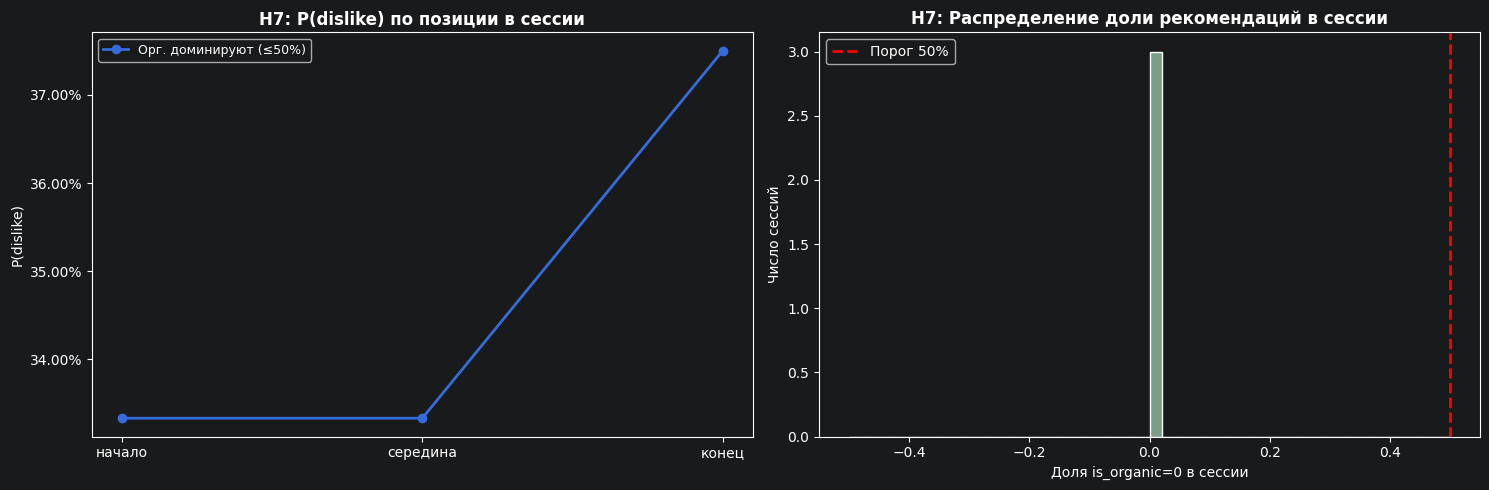

💾 h7_results.png


In [61]:
# Тест: Mann-Whitney конец vs начало в рек-сессиях
rec_sess = me[me['rec_share'] > 0.5]
start_d = rec_sess[rec_sess['pos_third'] == 'начало']['is_dislike'].values
end_d   = rec_sess[rec_sess['pos_third'] == 'конец']['is_dislike'].values

stat_h7, p_h7 = mannwhitneyu(end_d, start_d, alternative='greater')
h7_confirmed = p_h7 < 0.05
print(f'Mann-Whitney (конец > начало в рек-сессиях): p = {p_h7:.4e}')
print(f"{'✅ H7 ПОДТВЕРЖДАЕТСЯ' if h7_confirmed else '❌ H7 НЕ ПОДТВЕРЖДАЕТСЯ'}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: P(dislike) по трети сессии
thirds = ['начало', 'середина', 'конец']
for label, row in h7_pivot.iterrows():
    vals = [row.get(t, 0) for t in thirds]
    axes[0].plot(thirds, vals, marker='o', linewidth=2, label=label)
axes[0].set_title('H7: P(dislike) по позиции в сессии', fontweight='bold')
axes[0].set_ylabel('P(dislike)'); axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# График 2: распределение доли рекомендаций в сессиях
sess_shares = me[['uid','session_id','rec_share']].drop_duplicates()['rec_share']
axes[1].hist(sess_shares, bins=50, color='#7B9E87', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Порог 50%')
axes[1].set_title('H7: Распределение доли рекомендаций в сессии', fontweight='bold')
axes[1].set_xlabel('Доля is_organic=0 в сессии')
axes[1].set_ylabel('Число сессий'); axes[1].legend()

plt.tight_layout(); plt.savefig('h7_results.png', bbox_inches='tight'); plt.show()
print('💾 h7_results.png')

---
## 11. H8 — У опытных пользователей рекомендации эффективнее

**Формулировка:** В верхнем квартиле по числу взаимодействий Listen+ rate и like-rate для `is_organic=0` выше, чем в нижнем.  
**Контроль:** общая органическая активность пользователя как ковариата.

In [62]:
# Квартили по общей активности
user_activity_h8 = listens.groupby('uid').agg(
    total_listens  = ('listen_plus', 'count'),
    organic_share  = ('is_organic', 'mean')
).reset_index()
user_activity_h8['activity_quartile'] = pd.qcut(
    user_activity_h8['total_listens'], q=4,
    labels=['Q1 (мало)', 'Q2', 'Q3', 'Q4 (много)']
)

# Джойн обратно к listens
listens_h8 = listens.merge(user_activity_h8[['uid','activity_quartile','organic_share']], on='uid')

# Listen+ rate для рекомендаций по квартилям
rec_listens_h8 = listens_h8[listens_h8['is_organic'] == 0]
h8_listen = rec_listens_h8.groupby('activity_quartile')['listen_plus'].mean()

# Like-rate для рекомендаций по квартилям
like_flag_h8 = likes[['uid','item_id']].drop_duplicates()
like_flag_h8['liked'] = 1
rec_listen_agg = (
    rec_listens_h8.groupby(['uid','item_id','activity_quartile'])
    .size().reset_index(name='n')
)
rec_listen_agg = rec_listen_agg.merge(like_flag_h8, on=['uid','item_id'], how='left')
rec_listen_agg['liked'] = rec_listen_agg['liked'].fillna(0)
h8_like = rec_listen_agg.groupby('activity_quartile')['liked'].mean()

print('📊 H8 — Эффективность рекомендаций по квартилям активности:')
h8_summary = pd.DataFrame({'Listen+ rate': h8_listen, 'Like rate': h8_like}).round(4)
print(h8_summary.to_string())

# Тренд: Cuzick test (альтернатива — Spearman по квартилям)
q_numeric = {'Q1 (мало)': 1, 'Q2': 2, 'Q3': 3, 'Q4 (много)': 4}
x_trend = rec_listens_h8['activity_quartile'].map(q_numeric)
rho_trend, p_trend = spearmanr(x_trend, rec_listens_h8['listen_plus'])
print(f'\nTrend test (Spearman): ρ={rho_trend:.4f}, p={p_trend:.4e}')
h8_confirmed = p_trend < 0.05 and rho_trend > 0
print(f"{'✅ H8 ПОДТВЕРЖДАЕТСЯ' if h8_confirmed else '❌ H8 НЕ ПОДТВЕРЖДАЕТСЯ'}: тренд {'растёт' if rho_trend>0 else 'падает'} с активностью")

📊 H8 — Эффективность рекомендаций по квартилям активности:
                   Listen+ rate  Like rate
activity_quartile                         
Q1 (мало)                0.6652     0.0384
Q2                       0.6939     0.0508
Q3                       0.7046     0.0553
Q4 (много)               0.6724     0.0575

Trend test (Spearman): ρ=-0.0255, p=0.0000e+00
❌ H8 НЕ ПОДТВЕРЖДАЕТСЯ: тренд падает с активностью


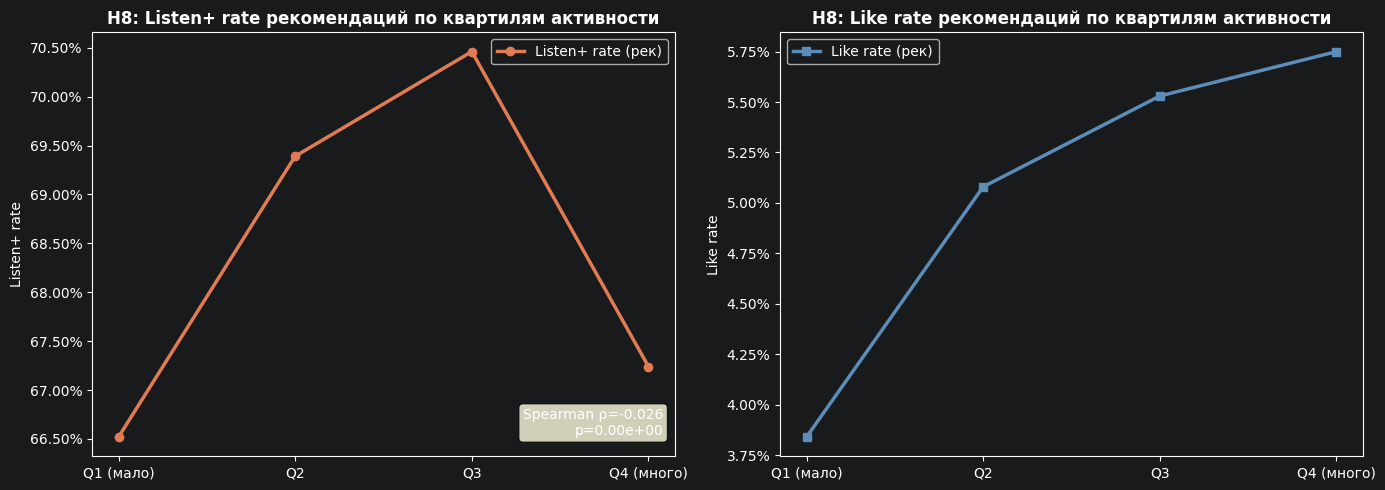

💾 h8_results.png


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
quartiles = h8_summary.index.tolist()
x_q = np.arange(len(quartiles))

axes[0].plot(quartiles, h8_summary['Listen+ rate'], marker='o', linewidth=2.5,
             color=COLORS[0], label='Listen+ rate (рек)')
axes[0].set_title('H8: Listen+ rate рекомендаций по квартилям активности', fontweight='bold')
axes[0].set_ylabel('Listen+ rate'); axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].text(0.98, 0.05, f'Spearman ρ={rho_trend:.3f}\np={p_trend:.2e}',
             transform=axes[0].transAxes, ha='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

axes[1].plot(quartiles, h8_summary['Like rate'], marker='s', linewidth=2.5,
             color=COLORS[1], label='Like rate (рек)')
axes[1].set_title('H8: Like rate рекомендаций по квартилям активности', fontweight='bold')
axes[1].set_ylabel('Like rate'); axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout(); plt.savefig('h8_results.png', bbox_inches='tight'); plt.show()
print('💾 h8_results.png')

---
## 12. H9 — Рекомендации, похожие на органику пользователя, лучше дослушиваются

**Формулировка:** Косинусное сходство рекомендованного трека со средним вектором последних 20 органических треков пользователя положительно коррелирует с Listen+.  
**Данные:** `embeddings.parquet` + `listens`.  
⚠️ Самая вычислительно затратная гипотеза — работаем на сэмпле пользователей.

In [ ]:
# ── Умная загрузка: только нужные item_id ────────────────────────────────────
import pyarrow.parquet as pq
from huggingface_hub import hf_hub_download

print('📥 Скачиваем файл embeddings.parquet...')
emb_path = hf_hub_download(
    repo_id='yandex/yambda',
    filename='embeddings.parquet',
    repo_type='dataset'
)
print(f'✅ Файл на диске: {emb_path}')

# Определяем нужные item_id заранее — только треки из сэмпла пользователей
sample_uids_h9 = np.random.default_rng(RANDOM_SEED).choice(
    listens['uid'].unique(), size=2000, replace=False
)
needed_items = set(
    listens[listens['uid'].isin(sample_uids_h9)]['item_id'].unique()
)
print(f'   Нужно эмбеддингов: {len(needed_items):,} из 7.72M')

# Читаем parquet батчами — не грузим всё в память
print('🔧 Читаем батчами, фильтруем на лету...')
pf = pq.ParquetFile(emb_path)
rows = []
for batch in pf.iter_batches(batch_size=100_000, columns=['item_id', 'normalized_embed']):
    df_batch = batch.to_pandas()
    filtered = df_batch[df_batch['item_id'].isin(needed_items)]
    if len(filtered) > 0:
        rows.append(filtered)
    # Можно добавить прогресс
    if len(rows) % 10 == 0:
        print(f'   Найдено {sum(len(r) for r in rows):,} эмбеддингов...', end='\r')

embeddings_df = pd.concat(rows, ignore_index=True)
print(f'\n✅ Загружено {len(embeddings_df):,} эмбеддингов (из {len(needed_items):,} нужных)')

📥 Скачиваем файл embeddings.parquet...


In [ ]:
import numpy as np

# Строим словарь item_id → normalized_embed
print('🔧 Строим словарь эмбеддингов...')
emb_dict = {}
for _, row in embeddings_df.iterrows():
    vec = np.array(row['normalized_embed'], dtype=np.float32)
    emb_dict[row['item_id']] = vec
print(f'✅ Эмбеддингов в словаре: {len(emb_dict):,}')

# Сэмпл: 2000 пользователей с ≥5 органическими и ≥1 рекомендательным прослушиванием
WINDOW = 20  # последних органических треков
N_USERS = 2000

user_counts = listens.groupby('uid')['is_organic'].value_counts().unstack(fill_value=0)
eligible_users = user_counts[
    (user_counts.get(1, 0) >= WINDOW) & (user_counts.get(0, 0) >= 1)
].index
sample_users = np.random.default_rng(RANDOM_SEED).choice(
    eligible_users, size=min(N_USERS, len(eligible_users)), replace=False
)
print(f'✅ Пользователей для анализа: {len(sample_users):,}')

listens_sample = listens[listens['uid'].isin(sample_users)].sort_values(['uid','abs_time_sec'])

In [ ]:
# Вычисляем косинусное сходство для каждого рекомендательного прослушивания
print('⏳ Вычисляем сходство (может занять 1–2 мин)...')
records = []

for uid, group in listens_sample.groupby('uid'):
    group = group.sort_values('abs_time_sec').reset_index(drop=True)
    organic_history = []  # буфер последних органических треков

    for _, row in group.iterrows():
        item_id = row['item_id']
        is_org  = row['is_organic']
        lp      = row['listen_plus']

        if is_org == 0 and len(organic_history) >= 3:
            # Рекомендательный трек — считаем сходство
            rec_vec = emb_dict.get(item_id)
            if rec_vec is not None:
                # Средний вектор последних WINDOW органических треков
                window_vecs = [emb_dict[i] for i in organic_history[-WINDOW:] if i in emb_dict]
                if window_vecs:
                    mean_vec = np.mean(window_vecs, axis=0)
                    # Косинусное сходство (векторы уже нормированы)
                    sim = float(np.dot(rec_vec, mean_vec) /
                                (np.linalg.norm(mean_vec) + 1e-9))
                    records.append({'uid': uid, 'item_id': item_id,
                                    'cosine_sim': sim, 'listen_plus': lp})

        elif is_org == 1:
            organic_history.append(item_id)

h9_df = pd.DataFrame(records)
print(f'✅ Рекомендательных событий с similarity: {len(h9_df):,}')
print(h9_df[['cosine_sim','listen_plus']].describe().round(4))

In [ ]:
# Spearman ρ: cosine_sim vs listen_plus
rho_h9, p_h9 = spearmanr(h9_df['cosine_sim'], h9_df['listen_plus'])
print(f'📐 Spearman ρ (cosine_sim ~ listen_plus): ρ={rho_h9:.4f}, p={p_h9:.4e}')
h9_confirmed = p_h9 < 0.05 and rho_h9 > 0
print(f"{'✅ H9 ПОДТВЕРЖДАЕТСЯ' if h9_confirmed else '❌ H9 НЕ ПОДТВЕРЖДАЕТСЯ'}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Listen+ rate по бакетам сходства
h9_df['sim_bin'] = pd.cut(h9_df['cosine_sim'], bins=5)
sim_listen = h9_df.groupby('sim_bin')['listen_plus'].mean()
axes[0].bar(range(len(sim_listen)), sim_listen.values, color='#5B8DB8', edgecolor='white')
axes[0].set_xticks(range(len(sim_listen)))
axes[0].set_xticklabels([str(b) for b in sim_listen.index], rotation=25, fontsize=8)
axes[0].set_title('H9: Listen+ rate по бакетам cosine similarity', fontweight='bold')
axes[0].set_ylabel('Listen+ rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].text(0.98, 0.05, f'ρ={rho_h9:.3f}\np={p_h9:.2e}',
             transform=axes[0].transAxes, ha='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: распределение cosine similarity по listen_plus
for lp, label, color in [(0,'Listen− (не дослушан)','#E07B54'),(1,'Listen+ (дослушан)','#5B8DB8')]:
    sub = h9_df[h9_df['listen_plus']==lp]['cosine_sim']
    axes[1].hist(sub, bins=40, alpha=0.6, density=True, label=label, color=color)
axes[1].set_title('H9: Распределение cosine similarity\nпо Listen+/Listen−', fontweight='bold')
axes[1].set_xlabel('Cosine similarity с органической историей')
axes[1].set_ylabel('Плотность'); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.savefig('h9_results.png', bbox_inches='tight'); plt.show()
print('💾 h9_results.png')

---
## 13. H10 — Асимметрия: реже лайкают, но чаще дизлайкают рекомендации

**Формулировка:** P(like|listen, рек) < P(like|listen, орг) И P(dislike|listen, рек) > P(dislike|listen, орг).  
**Нормировка:** знаменатель — количество прослушиваний в группе.  
**Поправка:** Bonferroni на два одновременных теста.

In [ ]:
# Агрегат прослушиваний
listen_agg_h10 = (
    listens.groupby(['uid','item_id'])
    .agg(is_organic=('is_organic','last'), n=('listen_plus','count'))
    .reset_index()
)

# Флаги лайка и дизлайка
lf = likes[['uid','item_id']].drop_duplicates(); lf['liked'] = 1
df_flag = dislikes[['uid','item_id']].drop_duplicates(); df_flag['disliked'] = 1

h10_df = (listen_agg_h10
          .merge(lf, on=['uid','item_id'], how='left')
          .merge(df_flag, on=['uid','item_id'], how='left'))
h10_df['liked']    = h10_df['liked'].fillna(0).astype(int)
h10_df['disliked'] = h10_df['disliked'].fillna(0).astype(int)

# P(like) и P(dislike) по группам
h10_rates = h10_df.groupby('is_organic')[['liked','disliked']].mean()
h10_rates.index = h10_rates.index.map(ORGANIC_LABELS)
print('📊 H10 — P(like) и P(dislike) нормированные на прослушивания:')
print(h10_rates.round(6).to_string())

# Chi-squared для like
ct_like    = pd.crosstab(h10_df['is_organic'], h10_df['liked'])
ct_dislike = pd.crosstab(h10_df['is_organic'], h10_df['disliked'])
chi2_like,    p_like,    _, _ = chi2_contingency(ct_like)
chi2_dislike, p_dislike, _, _ = chi2_contingency(ct_dislike)

# Bonferroni correction (2 теста)
p_like_adj    = min(p_like * 2, 1.0)
p_dislike_adj = min(p_dislike * 2, 1.0)

print(f'\nChi-squared like:    χ²={chi2_like:.2f},    p={p_like:.4e},    p_adj={p_like_adj:.4e}')
print(f'Chi-squared dislike: χ²={chi2_dislike:.2f}, p={p_dislike:.4e}, p_adj={p_dislike_adj:.4e}')

like_lower_for_rec    = h10_df[h10_df['is_organic']==0]['liked'].mean() < h10_df[h10_df['is_organic']==1]['liked'].mean()
dislike_higher_for_rec = h10_df[h10_df['is_organic']==0]['disliked'].mean() > h10_df[h10_df['is_organic']==1]['disliked'].mean()
h10_confirmed = p_like_adj < 0.05 and p_dislike_adj < 0.05 and like_lower_for_rec and dislike_higher_for_rec

# Asymmetry ratio
for org in [0, 1]:
    sub = h10_df[h10_df['is_organic']==org]
    ratio = sub['disliked'].mean() / (sub['liked'].mean() + 1e-9)
    print(f'  Asymmetry ratio (dislike/like) {ORGANIC_LABELS[org]}: {ratio:.3f}')
print(f"\n{'✅ H10 ПОДТВЕРЖДАЕТСЯ' if h10_confirmed else '❌ H10 НЕ ПОДТВЕРЖДАЕТСЯ (частично или полностью)'}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_10 = [ORGANIC_LABELS[0], ORGANIC_LABELS[1]]

for ax, col, title in [
    (axes[0], 'liked',    'H10: P(like | listen) по группам'),
    (axes[1], 'disliked', 'H10: P(dislike | listen) по группам'),
]:
    vals = [h10_df[h10_df['is_organic']==k][col].mean() for k in [0,1]]
    bars = ax.bar(labels_10, vals, color=[COLORS[0],COLORS[1]], width=0.45, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(f'P({col.replace("d","")})')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{val*100:.3f}%', ha='center', fontweight='bold')

plt.tight_layout(); plt.savefig('h10_results.png', bbox_inches='tight'); plt.show()
print('💾 h10_results.png')

---
## 14. H11 — Рекомендации увеличивают разнообразие потребления

**Формулировка:** В скользящих окнах 100 событий с преобладанием рекомендаций (>50%) энтропия item_id и средняя косинусная дистанция выше.  
**Метрики:** Shannon entropy + intra-list cosine diversity.

In [ ]:
from scipy.stats import entropy as scipy_entropy

WINDOW_SIZE = 100
STEP        = 50   # шаг скользящего окна
N_USERS_H11 = 1000

sample_uids_h11 = np.random.default_rng(RANDOM_SEED).choice(
    listens['uid'].unique(), size=N_USERS_H11, replace=False
)
listens_h11 = listens[listens['uid'].isin(sample_uids_h11)].sort_values(['uid','abs_time_sec'])

window_records = []

for uid, group in listens_h11.groupby('uid'):
    items    = group['item_id'].values
    organics = group['is_organic'].values

    if len(items) < WINDOW_SIZE:
        continue

    for start in range(0, len(items) - WINDOW_SIZE + 1, STEP):
        w_items = items[start:start + WINDOW_SIZE]
        w_org   = organics[start:start + WINDOW_SIZE]

        rec_share = (w_org == 0).mean()

        # Shannon entropy item_id
        _, counts = np.unique(w_items, return_counts=True)
        ent = float(scipy_entropy(counts, base=2))

        # Intra-list cosine diversity (среднее попарное расстояние)
        vecs = [emb_dict[i] for i in w_items if i in emb_dict]
        if len(vecs) >= 2:
            vecs_arr = np.array(vecs[:30])  # ограничиваем для скорости
            sims = vecs_arr @ vecs_arr.T
            np.fill_diagonal(sims, np.nan)
            diversity = float(1 - np.nanmean(sims))
        else:
            diversity = np.nan

        window_records.append({'uid': uid, 'rec_share': rec_share,
                               'entropy': ent, 'diversity': diversity})

h11_df = pd.DataFrame(window_records)
h11_df['rec_dominated'] = h11_df['rec_share'] > 0.5
print(f'✅ Окон для анализа: {len(h11_df):,}')
print(h11_df.groupby('rec_dominated')[['entropy','diversity']].mean().round(4))

In [ ]:
# Mann-Whitney тесты
rec_ent = h11_df[h11_df['rec_dominated']]['entropy'].dropna()
org_ent = h11_df[~h11_df['rec_dominated']]['entropy'].dropna()
rec_div = h11_df[h11_df['rec_dominated']]['diversity'].dropna()
org_div = h11_df[~h11_df['rec_dominated']]['diversity'].dropna()

_, p_ent = mannwhitneyu(rec_ent, org_ent, alternative='two-sided')
_, p_div = mannwhitneyu(rec_div, org_div, alternative='two-sided')

print(f'Entropy:   рек={rec_ent.mean():.3f} vs орг={org_ent.mean():.3f}, p={p_ent:.4e}')
print(f'Diversity: рек={rec_div.mean():.4f} vs орг={org_div.mean():.4f}, p={p_div:.4e}')

h11_confirmed = p_ent < 0.05 and rec_ent.mean() > org_ent.mean()
print(f"\n{'✅ H11 ПОДТВЕРЖДАЕТСЯ' if h11_confirmed else '❌ H11 НЕ ПОДТВЕРЖДАЕТСЯ'} по entropy")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, p_val in [
    (axes[0], 'entropy',   'H11: Shannon entropy item_id в окне', p_ent),
    (axes[1], 'diversity', 'H11: Intra-list cosine diversity в окне', p_div),
]:
    for dominated, label, color in [(True,'Рек. доминируют','#E07B54'),(False,'Орг. доминируют','#5B8DB8')]:
        sub = h11_df[h11_df['rec_dominated']==dominated][col].dropna()
        ax.hist(sub, bins=40, alpha=0.6, density=True, label=label, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Плотность'); ax.legend(fontsize=9)
    ax.text(0.98, 0.95, f'p={p_val:.2e}', transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(); plt.savefig('h11_results.png', bbox_inches='tight'); plt.show()
print('💾 h11_results.png')

---
## 15. Итоговая сводка

In [ ]:
print('=' * 60)
print('ИТОГОВАЯ СВОДКА')
print('=' * 60)

# H1
h1_confirmed = p_value < 0.05
print(f"\nH1 — Listen+ ниже для рекомендаций:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h1_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  Mann-Whitney p = {p_value:.4e}, rank-biserial r = {r_rb:.4f}")
listen_plus_rates = listens_h1.groupby('is_organic')['listen_plus'].mean()
if 0 in listen_plus_rates and 1 in listen_plus_rates:
    print(f"  Listen+ rate: органич. {listen_plus_rates[1]*100:.1f}% vs рекоменд. {listen_plus_rates[0]*100:.1f}%")

# H2
h2_confirmed = p_chi2 < 0.05 and ci_low > 0
print(f"\nH2 — P(dislike) выше для рекомендаций:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h2_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  χ² p={p_chi2:.4e}, OR={odds_ratio:.4f}")

# H3
print(f"\nH3 — Дизлайки рекомендательных чаще отменяются:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h3_confirmed and or_h3 > 1 else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  χ² p={p_h3:.4e}, OR={or_h3:.4f}")

# H4
print(f"\nH4 — Корреляция ratio–like слабее для рекомендаций:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h4_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  ρ_рек={results_h4[0]['rho']:.4f}, ρ_орг={results_h4[1]['rho']:.4f}, Fisher z p={p_z_h4:.4e}")

# H5
print(f"\nH5 — Listen+ снижается быстрее с длиной для рекомендаций:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h5_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  Interaction term (is_organic×length): {int_coef:+.4f}")

# H6
print(f"\nH6 — Перемотка (ratio>100%) чаще у органики:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h6_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  χ² p={p_h6:.4e}, OR(орг/рек)={or_h6:.4f}")

# H7
print(f"\nH7 — Усталость: P(dislike) растёт к концу рек-сессий:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h7_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  Mann-Whitney p={p_h7:.4e}")

# H8
print(f"\nH8 — Опытные пользователи: рекомендации эффективнее:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h8_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  Trend Spearman ρ={rho_trend:.4f}, p={p_trend:.4e}")

# H9
print(f"\nH9 — Аудио-похожесть → лучше дослушивается:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h9_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  Spearman ρ={rho_h9:.4f}, p={p_h9:.4e}")

# H10
print(f"\nH10 — Асимметрия like/dislike для рекомендаций:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h10_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА (частично)'}")
print(f"  p_like_adj={p_like_adj:.4e}, p_dislike_adj={p_dislike_adj:.4e}")

# H11
print(f"\nH11 — Рекомендации увеличивают разнообразие:")
print(f"  {'✅ ПОДТВЕРЖДЕНА' if h11_confirmed else '❌ НЕ ПОДТВЕРЖДЕНА'}")
print(f"  Entropy: p={p_ent:.4e} | Diversity: p={p_div:.4e}")

print()
print('=' * 60)
print('Все гипотезы протестированы!')
print('=' * 60)